# Automated Macro-Financial Risk Intelligence Pipeline

This notebook documents an end-to-end automated macro-financial analytics pipeline built in Python.

The system retrieves real economic data (FRED API), standardizes multiple macroeconomic indicators, engineers financial features, applies a rule-based risk engine, computes a composite Macro Financial Stress Index (MFSI) with short-term forecasting, and generates automated Excel and PDF reports.

## Submission Note

This submission includes the full Python automation pipeline inside the `src/` folder.

Main execution command:

`python src/run_pipeline.py`

The pipeline automates:
- data acquisition from FRED
- data cleaning and monthly harmonisation
- feature engineering
- rule-based macro risk scoring
- SQLite storage
- automated chart generation
- Excel reporting
- PDF executive reporting

## Project Objective

The objective of this project is to build an automated macroeconomic monitoring system that supports FP&A and financial decision-making.

Instead of manually reviewing macroeconomic indicators, the system collects, transforms and interprets key macroeconomic signals into a structured risk framework.

This makes the monitoring process more repeatable, scalable and useful for budgeting, planning discussions and executive decision support.

## Data Acquisition


Macroeconomic indicators are retrieved programmatically from the Federal Reserve Economic Data (FRED API).

The following indicators are used:

- **Consumer Price Index (CPI):** captures inflation pressure and changes in the cost environment.
- **Unemployment Rate:** reflects labour market weakness and broader economic deterioration.
- **Federal Funds Rate:** captures monetary policy tightening and short-term borrowing pressure.
- **10-Year Treasury Yield:** reflects long-term market expectations and financial conditions.

These indicators were selected because they represent complementary dimensions of macro-financial risk relevant to FP&A and strategic planning.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/macro_us_with_index.csv")
df.tail()

,date,us_cpi,us_unrate,us_fedfunds,us_10y,us_cpi_mom_pct,us_cpi_yoy_pct,us_cpi_roll3,us_cpi_roll6,us_unrate_mom_pct,...,risk_score,alerts,risk_level,z_cpi,z_unrate,z_fedfunds,z_10y,macro_stress_index,stress_level,macro_strategy
753,2025-11-01,325.063,4.5,3.88,4.093889,NaN,2.696444,NaN,NaN,NaN,...,1,Bond Yield Stress,LOW RISK,-0.416088,-0.787130,-0.267629,-0.586718,-2.057564,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
754,2025-12-01,326.031,4.4,3.72,4.143182,0.297788,2.653304,NaN,NaN,-2.222222,...,1,Bond Yield Stress,LOW RISK,-0.431520,-0.845385,-0.311564,-0.569934,-2.158403,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
755,2026-01-01,326.588,4.3,3.64,4.213500,0.170843,2.391201,325.894000,NaN,-2.272727,...,1,Bond Yield Stress,LOW RISK,-0.525282,-0.903641,-0.333531,-0.545992,-2.308446,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
756,2026-02-01,327.460,4.4,3.64,4.125789,0.267003,2.434004,326.693000,NaN,2.325581,...,2,Rising Unemployment Risk; Bond Yield Stress,LOW RISK,-0.509970,-0.845385,-0.333531,-0.575856,-2.264743,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
757,2026-03-01,330.293,4.3,3.64,4.245909,0.865144,3.285958,328.113667,NaN,-2.272727,...,1,Bond Yield Stress,LOW RISK,-0.205201,-0.903641,-0.333531,-0.534957,-1.977330,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."


## Data Cleaning and Preparation

Before analysis, all macroeconomic series were cleaned and standardised into a comparable monthly format.

The preparation process included:
- date standardisation,
- monthly harmonisation across indicators,
- handling missing values created by rolling calculations and percentage changes,
- and merging all variables into a single analytical dataset.

For lower-frequency macroeconomic indicators, the latest monthly observation was retained.  
For the 10-Year Treasury Yield, a monthly average was used to reduce daily market noise and improve comparability.

These decisions were made to improve consistency, interpretability and analytical reliability.

In [2]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 758 non-null    datetime64[ns]
 1   us_cpi               758 non-null    float64       
 2   us_unrate            758 non-null    float64       
 3   us_fedfunds          758 non-null    float64       
 4   us_10y               758 non-null    float64       
 5   us_cpi_mom_pct       757 non-null    float64       
 6   us_cpi_yoy_pct       758 non-null    float64       
 7   us_cpi_roll3         756 non-null    float64       
 8   us_cpi_roll6         753 non-null    float64       
 9   us_unrate_mom_pct    757 non-null    float64       
 10  us_unrate_yoy_pct    758 non-null    float64       
 11  us_unrate_roll3      756 non-null    float64       
 12  us_unrate_roll6      753 non-null    float64       
 13  us_fedfunds_mom_pct  758 non-null  

## Feature Engineering

All indicators were standardised to monthly frequency and transformed into additional analytical variables.

Key engineered features include:
- Month-over-Month (MoM) percentage change
- Year-over-Year (YoY) percentage change
- Rolling averages (3 and 6 months)

These engineered features help identify short-term momentum, longer-term trend changes and potential turning points relevant to FP&A scenario planning.

In [3]:
cols = [
    "date",
    "us_cpi_yoy_pct",
    "us_unrate",
    "us_fedfunds",
    "us_10y",
    "macro_stress_index",
    "stress_level",
    "macro_strategy",
]
df[cols].tail(12)

,date,us_cpi_yoy_pct,us_unrate,us_fedfunds,us_10y,macro_stress_index,stress_level,macro_strategy
746,2025-03-01,2.381981,4.2,4.33,4.280476,-2.157727,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
747,2025-04-01,2.325388,4.2,4.33,4.279048,-2.178459,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
748,2025-05-01,2.377265,4.3,4.33,4.423810,-2.052357,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
749,2025-06-01,2.680454,4.1,4.33,4.383500,-2.074133,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
750,2025-07-01,2.742618,4.3,4.33,4.391818,-1.932551,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
751,2025-08-01,2.938592,4.3,4.33,4.264762,-1.905706,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
752,2025-09-01,3.022572,4.4,4.22,4.120476,-1.896740,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
753,2025-11-01,2.696444,4.5,3.88,4.093889,-2.057564,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
754,2025-12-01,2.653304,4.4,3.72,4.143182,-2.158403,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."
755,2026-01-01,2.391201,4.3,3.64,4.213500,-2.308446,VERY LOW,"Pro-Growth regime: Favor Equities, Tech, Small..."


## Risk Model Design

A rule-based macro risk engine was developed to convert multiple economic indicators into an interpretable risk signal.

The model increases risk when inflation is elevated, labour market conditions weaken, policy rates remain high or bond yields suggest financial stress.

A rule-based approach was chosen because it is:
- transparent,
- easy to explain,
- and practical for business settings where interpretability matters.

Higher weight was given to inflation and interest-rate variables because these tend to have a more direct impact on borrowing costs, planning assumptions and margin pressure.

Below is the latest available observation from the risk engine output.

In [4]:
df_risk = pd.read_csv("../data/processed/macro_us_with_risk.csv")
df_risk["date"] = pd.to_datetime(df_risk["date"])

latest_risk = df_risk.sort_values("date").iloc[-1]
latest_risk

date                   2026-03-01 00:00:00
us_cpi                             330.293
us_unrate                              4.3
us_fedfunds                           3.64
us_10y                            4.245909
us_cpi_mom_pct                    0.865144
us_cpi_yoy_pct                    3.285958
us_cpi_roll3                    328.113667
us_cpi_roll6                           NaN
us_unrate_mom_pct                -2.272727
us_unrate_yoy_pct                 2.380952
us_unrate_roll3                   4.333333
us_unrate_roll6                        NaN
us_fedfunds_mom_pct                    0.0
us_fedfunds_yoy_pct             -15.935335
us_fedfunds_roll3                     3.64
us_fedfunds_roll6                 3.768333
us_10y_mom_pct                    2.911434
us_10y_yoy_pct                   -0.807553
us_10y_roll3                      4.195066
us_10y_roll6                      4.147348
risk_score                               1
alerts                   Bond Yield Stress
risk_level 

## Analysis and Insight Generation

The final dataset shows that raw macroeconomic indicators can be transformed into a structured risk-monitoring framework.

By combining inflation, unemployment, policy rates and bond yields, the model produces an interpretable summary of macro-financial conditions.

This is useful for FP&A because it supports a more systematic view of:
- inflation pressure,
- financial tightening,
- potential stress conditions,
- and planning risk.

The project moves beyond simple data collection by converting time-series data into business-relevant signals through scoring, engineered features and a composite stress index.

## Additional Visual Analysis

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_recent = df[df["date"] >= "2006-01-01"].copy()
df_risk_recent = df_risk[df_risk["date"] >= "2006-01-01"].copy()

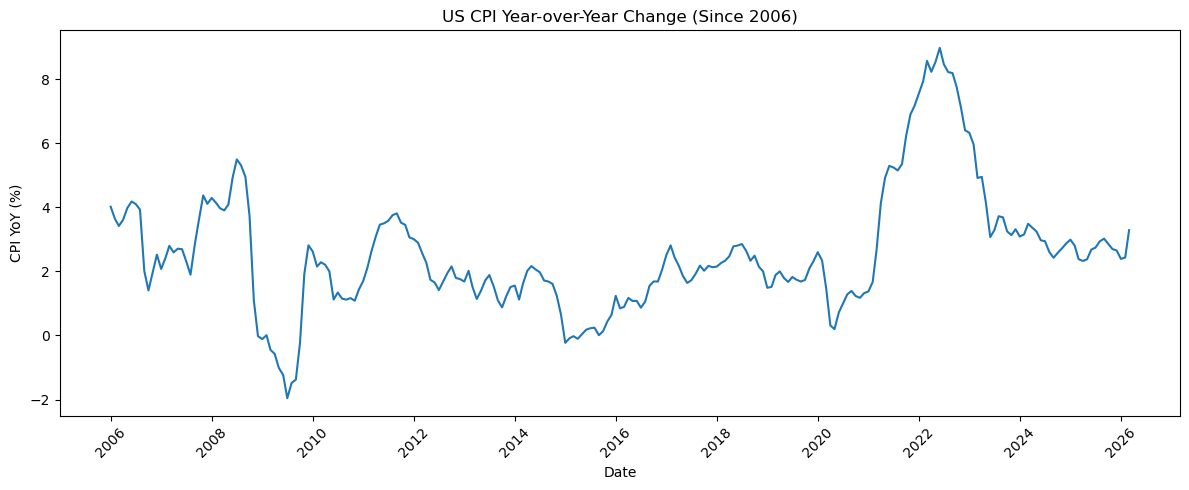

In [6]:
plt.figure(figsize=(12,5))
plt.plot(df_recent["date"], df_recent["us_cpi_yoy_pct"])
plt.title("US CPI Year-over-Year Change (Since 2006)")
plt.xlabel("Date")
plt.ylabel("CPI YoY (%)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The CPI year-over-year series highlights changes in inflation pressure over time. Persistent inflation is important for FP&A because it can affect cost assumptions, pricing decisions and margin planning.

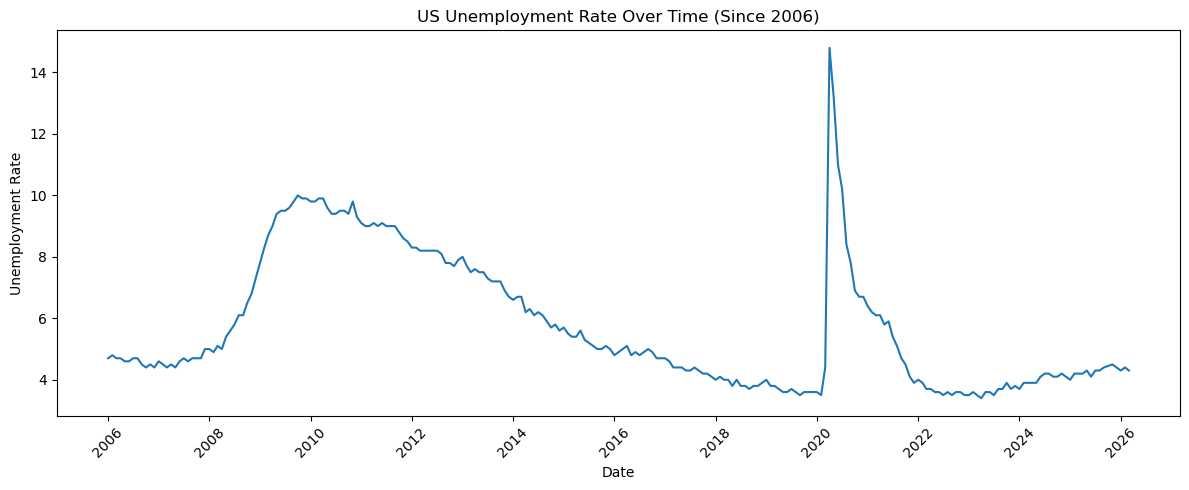

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df_recent["date"], df_recent["us_unrate"])
plt.title("US Unemployment Rate Over Time (Since 2006)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The unemployment rate provides a view of labour market health. Increases in unemployment may indicate broader economic weakness and a more cautious planning environment.

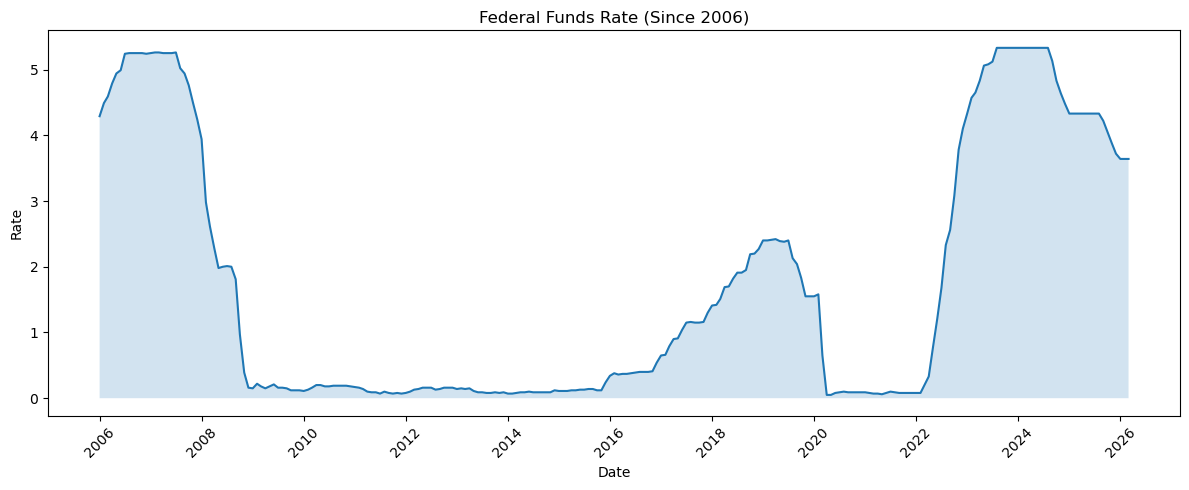

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df_recent["date"], df_recent["us_fedfunds"])
plt.fill_between(df_recent["date"], df_recent["us_fedfunds"], alpha=0.2)
plt.title("Federal Funds Rate (Since 2006)")
plt.xlabel("Date")
plt.ylabel("Rate")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The Federal Funds Rate reflects the stance of monetary policy. Higher rates typically increase financing costs and can influence investment timing, borrowing decisions and forecasting assumptions.

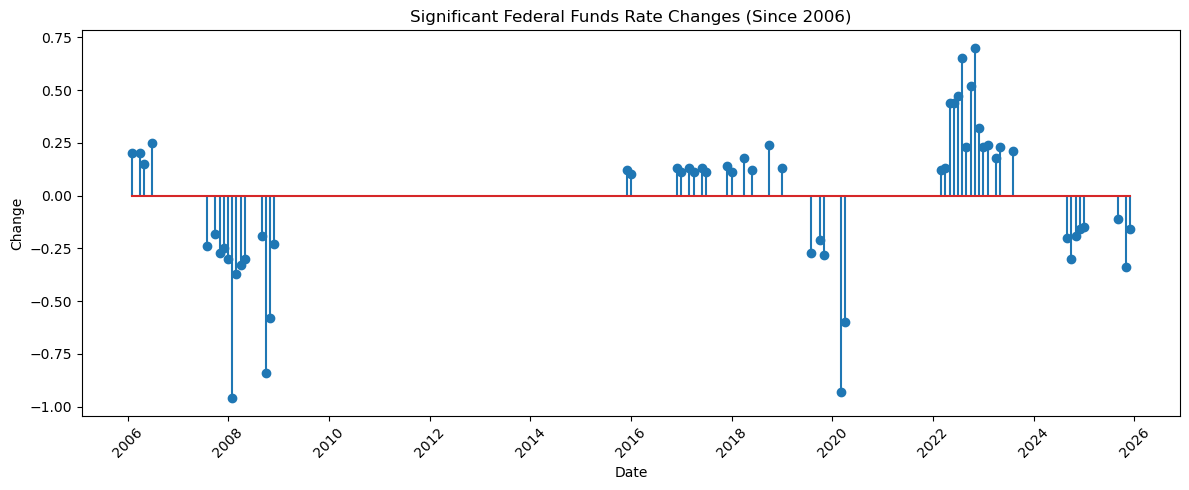

In [9]:
df_recent["fedfunds_change"] = df_recent["us_fedfunds"].diff()
df_changes = df_recent[df_recent["fedfunds_change"].abs() > 0.1]

plt.figure(figsize=(12,5))
plt.stem(df_changes["date"], df_changes["fedfunds_change"])

plt.title("Significant Federal Funds Rate Changes (Since 2006)")
plt.xlabel("Date")
plt.ylabel("Change")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

While the level of the Federal Funds Rate shows the broader monetary policy stance, this chart highlights periods of active rate changes.

These movements are particularly important for FP&A, as sudden increases or decreases in interest rates can significantly impact financing costs, investment decisions and forecasting assumptions.

The combination of level-based and change-based visualisations provides a more complete view of macroeconomic dynamics, improving both interpretability and decision support.

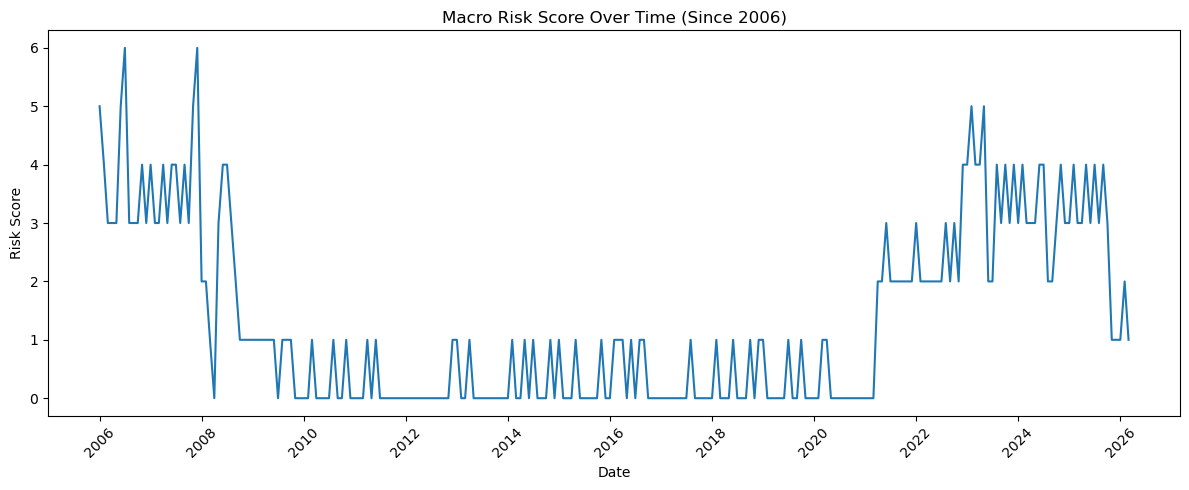

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df_risk_recent["date"], df_risk_recent["risk_score"])
plt.title("Macro Risk Score Over Time (Since 2006)")
plt.xlabel("Date")
plt.ylabel("Risk Score")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The risk score consolidates multiple macroeconomic warning signals into a single interpretable measure. This improves communication with non-technical stakeholders and supports faster risk monitoring.

In [11]:
df_risk[["date", "risk_score", "risk_level", "alerts"]].tail(12)

,date,risk_score,risk_level,alerts
759,2025-04-01,3,MEDIUM RISK,High Interest Rate Environment; Bond Yield Stress
760,2025-05-01,4,MEDIUM RISK,Rising Unemployment Risk; High Interest Rate E...
761,2025-06-01,3,MEDIUM RISK,High Interest Rate Environment; Bond Yield Stress
762,2025-07-01,4,MEDIUM RISK,Rising Unemployment Risk; High Interest Rate E...
763,2025-08-01,3,MEDIUM RISK,High Interest Rate Environment; Bond Yield Stress
764,2025-09-01,4,MEDIUM RISK,Rising Unemployment Risk; High Interest Rate E...
765,2025-10-01,3,MEDIUM RISK,High Interest Rate Environment; Bond Yield Stress
766,2025-11-01,1,LOW RISK,Bond Yield Stress
767,2025-12-01,1,LOW RISK,Bond Yield Stress
768,2026-01-01,1,LOW RISK,Bond Yield Stress


The most recent observations show how the rule-based framework translates macroeconomic conditions into risk levels and alert categories, making the final output more actionable than raw indicator monitoring alone.

Recent observations indicate relatively stable macro-financial conditions, with consistently low risk scores despite moderate fluctuations in individual indicators.

This suggests that, although certain signals such as bond yields may exhibit short-term stress, the broader macroeconomic environment does not currently indicate elevated systemic risk.

## Macro Stress Index (Last 15 Years + Forecast)

The pipeline generates a zoomed chart including a short-term 3-month forecast.

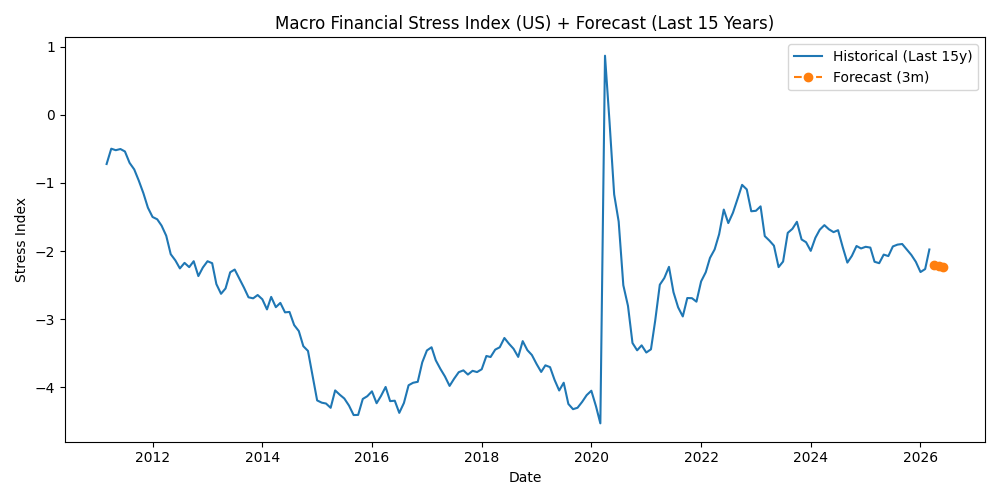

In [12]:
from IPython.display import Image, display
display(Image(filename="../reports/macro_stress_index_recent.png"))

The Macro Financial Stress Index provides a consolidated view of macro-financial conditions over time.

This makes it easier to identify broad stress regimes and communicate results to non-technical stakeholders. The inclusion of a short-term forecast also improves the usefulness of the output for planning and forward-looking discussion.

## Automation & Reporting

The full workflow is automated via the `run_pipeline.py` script, which executes:

1. API data ingestion (FRED)
2. Data cleaning and monthly standardisation
3. Feature engineering (MoM, YoY, Rolling)
4. Rule-based risk scoring and regime classification
5. SQLite database storage
6. SQL-based executive queries
7. Excel report generation
8. PDF executive briefing
9. Logging

This automation improves reproducibility, reduces manual effort and supports a more scalable reporting workflow.

Key deliverables produced:

- Excel Report: `reports/macro_us_report.xlsx`
- Executive PDF: `reports/macro_us_executive_brief.pdf`
- SQLite Database: `data/processed/macro.db`
- Automation Log: `logs/automation.log`

In [13]:
import os

processed_files = os.listdir("../data/processed")
reports = os.listdir("../reports")
logs = os.listdir("../logs")

print("Processed datasets:")
for f in processed_files:
    print("-", f)

print("\nGenerated reports:")
for r in reports:
    print("-", r)

print("\nLogs:")
for l in logs:
    print("-", l)

Processed datasets:
- macro.db
- macro_us_index_forecast.csv
- macro_us_monthly.csv
- macro_us_with_index.csv
- macro_us_with_risk.csv
- sql_last12.csv
- sql_snapshot.csv
- top_high_stress_periods.csv
- top_low_stress_periods.csv

Generated reports:
- macro_stress_index.png
- macro_stress_index_full.png
- macro_stress_index_recent.png
- macro_us_executive_brief.pdf
- macro_us_report.xlsx

Logs:
- automation.log


In [14]:
log_path = "../logs/automation.log"

with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

print("Last pipeline execution logs:\n")
print("".join(lines[-15:]))

Last pipeline execution logs:

          date  macro_stress_index stress_level
766 2025-11-01           -2.057564     VERY LOW
767 2025-12-01           -2.158403     VERY LOW
768 2026-01-01           -2.308446     VERY LOW
769 2026-02-01           -2.264743     VERY LOW
770 2026-03-01           -1.977330     VERY LOW
✅ Chart with forecast saved to reports/macro_stress_index.png
✅ Charts saved:
 - reports/macro_stress_index_full.png
 - reports/macro_stress_index_recent.png
2026-04-12 19:40:57,571 | INFO | Running us_excel_report.py
2026-04-12 19:40:58,996 | INFO | ✅ Excel Report Generated: ../reports/macro_us_report.xlsx
2026-04-12 19:40:58,996 | INFO | Running us_pdf_report.py
2026-04-12 19:40:59,678 | INFO | ✅ PDF upgraded with executive insight: C:\Users\gabri\Desktop\fpna-macro-risk-intelligence-system\reports\macro_us_executive_brief.pdf
2026-04-12 19:40:59,678 | INFO | FULL PIPELINE EXECUTED SUCCESSFULLY



In [15]:
import os

pdf_path = "../reports/macro_us_executive_brief.pdf"

print("PDF exists:", os.path.exists(pdf_path))
print("PDF path:", pdf_path)
print("PDF size (bytes):", os.path.getsize(pdf_path))

PDF exists: True
PDF path: ../reports/macro_us_executive_brief.pdf
PDF size (bytes): 55664


The successful generation of the executive PDF report confirms that the pipeline produces final business-ready outputs, demonstrating a complete end-to-end automated reporting workflow.

The automation pipeline was executed successfully outside the notebook environment using the command:

`python src/run_pipeline.py`

The outputs displayed above confirm that all steps were completed, including:
- data acquisition,
- transformation,
- feature engineering,
- risk scoring,
- database storage,
- and report generation.

The notebook focuses on presenting and analysing the outputs of this automated process rather than re-running the pipeline in an interactive environment.

## Limitations and Future Improvements

This project has some limitations.

The model uses a relatively small set of indicators and a rule-based scoring framework, which improves transparency but may simplify complex macroeconomic relationships.

Future improvements could include:
- expanding the range of indicators,
- integrating additional data sources,
- testing alternative weighting approaches,
- and validating the framework against known macroeconomic stress periods.

## Final Conclusion

This project demonstrates that macroeconomic monitoring can be automated and translated into a practical FP&A risk intelligence workflow.

By combining acquisition, cleaning, feature engineering, scoring and reporting, the system produces outputs that are both technically reproducible and more useful for decision support.

The final solution improves the interpretation of macroeconomic conditions and provides a stronger foundation for future scenario analysis and planning applications.

Ultimately, the system demonstrates how macroeconomic data can be transformed into a structured and automated decision-support tool, improving both analytical depth and business usability.